# Chapter 3: How to Predict Emergence

A curve can explain yesterday's observations beautifully and still fail at tomorrow's scale. The difference between explanation and forecasting lies partly in chronology: which observations were available when the family and coefficients were selected? If a test outcome helps choose the model, it is no longer independent evidence for the prediction it influenced.

This notebook gives development and test observations separate fields. The coefficients are fitted from development data alone. The test data then scores that frozen forecast. The changed case leaves the fit untouched while changing unseen outcomes, making it impossible to confuse a stable fitted line with a successful prediction. This is a narrow implemented forecasting protocol, not a universal emergence predictor.

**Outcome:** Fit a declared curve on development data and score a separate test.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

The declared family is y=alpha+beta f(x), where f(x)=x for a linear fit or f(x)=log(x) for a log fit. Let z_i=f(x_i). Least squares gives beta=sum_i(z_i-z_bar)(y_i-y_bar)/sum_i(z_i-z_bar)^2 and alpha=y_bar-beta z_bar. Variation in the development scales is necessary because a zero denominator leaves the slope unidentified.

At a test scale x_j, the frozen prediction is y_hat_j=alpha+beta f(x_j). Residuals are y_hat_j-y_j. Test RMSE is sqrt(mean residual squared), while bias is the signed mean residual. RMSE measures magnitude; bias distinguishes systematic overprediction from underprediction. Neither is a probability of being correct.

The log family requires positive scales and interprets equal multiplicative scale changes as equal increments in its transformed coordinate. Family selection is part of the prospective protocol and must occur before seeing test outcomes. The software cannot verify the historical order of an external experiment, but it rejects overlapping development and test scales and never uses test y values in the fit.

## A calculation you can run

Supply two aligned development vectors and two aligned test vectors. State the family explicitly. The function validates finite values, dimensional alignment, development variation, and separation of scale sets. It computes coefficients, frozen predictions, residuals, RMSE, and bias.

The forecast and unseen-observation figures share test scale and score units. The residual figure makes errors visible rather than hiding them beneath a fitted line. Run the default case, save its coefficients, and predict what will happen when only test_y changes. The coefficients must remain identical. If they move, test evidence leaked into fitting. For real data, keep a timestamped forecast artifact or preregistered protocol beside the exported result to support the prospective claim.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 3
inputs = {'development_x': [1, 2, 3],
 'development_y': [0.2, 0.3, 0.4],
 'test_x': [4, 5],
 'test_y': [0.5, 0.6],
 'family': 'linear'}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 3: prospective-forecast
Can a frozen forecast predict unseen capability observations?
Evidence: constructed teaching example

Calculated quantities:
{
  "family": "linear",
  "slope": 0.1,
  "intercept": 0.1,
  "predictions": [
    0.5,
    0.6
  ],
  "test_rmse": 0.0,
  "test_bias": 0.0
}

Interpretation:
Only development observations fit the declared family. Test outcomes score the frozen forecast and never update its coefficients.

Assumptions:
- Family selection is declared before the test is inspected.
- Least squares describes the supplied development observations.

Limitations:
- Extrapolation validity and mechanism are not established by a good fit.
- Protocol metadata is needed to establish real prospective separation.

Execution: completed locally; constructed inputs are not deployment measurements.


The default development line has slope 0.1 and intercept 0.1. It predicts 0.5 and 0.6 at unseen scales 4 and 5, matching the supplied test outcomes. RMSE and bias are zero up to numerical rounding.

The changed test outcomes are 0.8 and 0.95. The forecast remains 0.5 and 0.6 because the development data did not change. Residuals become -0.3 and -0.35, with negative bias and a positive RMSE. That failure is informative. Refitting after seeing it might improve the retrospective graph, but it would not repair the original prospective forecast.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


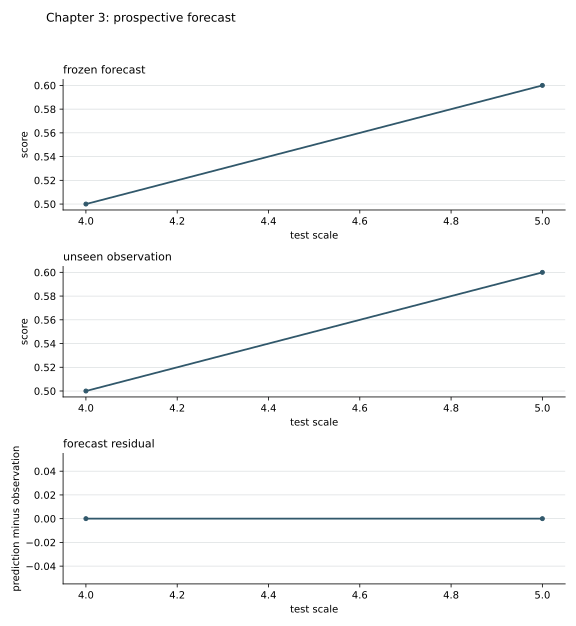

In [3]:
display(SVG(figure_svg(report)))

**Figure 3.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The simplest leakage pattern is to move a disappointing test observation into the development set and continue calling the remaining assessment unseen. Another is to inspect several families against the same test outcomes and report only the best one. Both use the test to shape the prediction, so the reported errors cease to measure the original prospective protocol.

The implementation checks explicit scale overlap, but it cannot detect hidden reuse, shared tasks, or a family chosen after reading test results. Those are evidence-management problems. Record the family, data boundary, fit command, and forecast before opening the withheld outcome file.

A successful linear or log extrapolation also does not reveal an emergence mechanism. It is conditional performance of one declared family over one supplied range. New environments or measurement rules can break that relationship even if the development residuals were tiny.

Chapter 3: prospective-forecast
Can a frozen forecast predict unseen capability observations?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "family": "linear",
  "slope": 0.1,
  "intercept": 0.1,
  "predictions": [
    0.5,
    0.6
  ],
  "test_rmse": 0.3259601203,
  "test_bias": -0.325
}

Interpretation:
Only development observations fit the declared family. Test outcomes score the frozen forecast and never update its coefficients.

Assumptions:
- Family selection is declared before the test is inspected.
- Least squares describes the supplied development observations.

Limitations:
- Extrapolation validity and mechanism are not established by a good fit.
- Protocol metadata is needed to establish real prospective separation.

Execution: completed locally; constructed inputs are not deployment measurements.


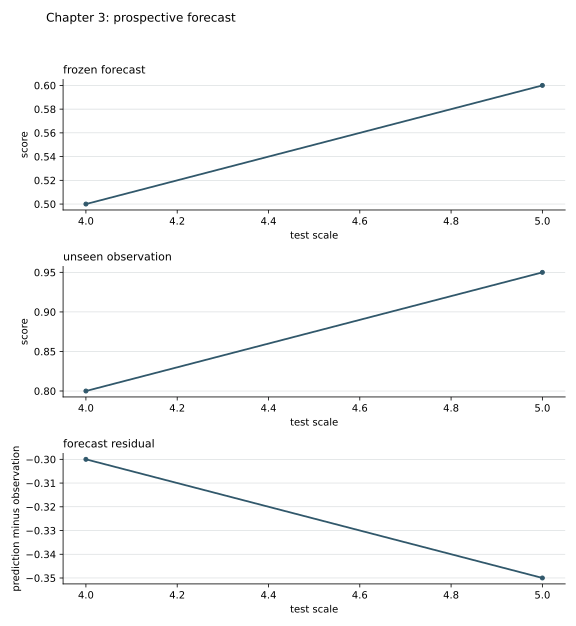

In [4]:
changed_inputs = {'development_x': [1, 2, 3],
 'development_y': [0.2, 0.3, 0.4],
 'test_x': [4, 5],
 'test_y': [0.8, 0.95],
 'family': 'linear'}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 3.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer data follows a logarithmic family. Doubling scale adds approximately log(2) to its outcome. Fit in log coordinates, then predict at scales 8 and 16. The slope is approximately 1 and the intercept approximately zero, so the predictions are approximately 2.0794 and 2.7726.

When applying the method locally, define the forecast target before choosing the family. It might be a continuous score, a completion probability, or another declared quantity. The runtime allows finite targets without pretending all are probabilities. Explain the target units and score transformation in the accompanying report. If a bounded probability is required, this unconstrained regression may be the wrong family.

In [5]:
transfer_inputs = {'development_x': [1, 2, 4],
 'development_y': [0, 0.69314718056, 1.38629436112],
 'test_x': [8, 16],
 'test_y': [2.07944154168, 2.77258872224],
 'family': 'log'}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 3: prospective-forecast
Can a frozen forecast predict unseen capability observations?
Evidence: constructed transfer example

Calculated quantities:
{
  "family": "log",
  "slope": 1.0,
  "intercept": 0.0,
  "predictions": [
    2.079441542,
    2.772588722
  ],
  "test_rmse": 0.0,
  "test_bias": 0.0
}

Interpretation:
Only development observations fit the declared family. Test outcomes score the frozen forecast and never update its coefficients.

Assumptions:
- Family selection is declared before the test is inspected.
- Least squares describes the supplied development observations.

Limitations:
- Extrapolation validity and mechanism are not established by a good fit.
- Protocol metadata is needed to establish real prospective separation.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **development_x:** At least two development scales with variation.
- **development_y:** Aligned finite development observations.
- **test_x:** Separate unseen scales, with no development overlap.
- **test_y:** Aligned withheld observations used only for scoring.
- **family:** linear or log, declared before inspecting test outcomes.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch03.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 3: prospective-forecast
Can a frozen forecast predict unseen capability observations?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "family": "log",
  "slope": 1.0,
  "intercept": 0.0,
  "predictions": [
    2.079441542,
    2.772588722
  ],
  "test_rmse": 0.0,
  "test_bias": 0.0
}

Interpretation:
Only development observations fit the declared family. Test outcomes score the frozen forecast and never update its coefficients.

Assumptions:
- Family selection is declared before the test is inspected.
- Least squares describes the supplied development observations.

Limitations:
- Extrapolation validity and mechanism are not established by a good fit.
- Protocol metadata is needed to establish real prospective separation.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. What are default fit coefficients?

2. Does the changed test update the fit?

3. Why must log-family scales be positive?

Answers: [separate solutions](../solutions/ch03.md). Try the calculation before opening them.

## Summary

A forecast is prospective only when its choices are frozen before the outcomes used to evaluate it. This computation separates development fitting from test scoring and reports both magnitude and direction of error. The changed case preserves coefficients while exposing forecast failure; the transfer case changes the declared family. Good fit does not establish mechanism, universality, or calibration. Preserve the chronology and input boundary so the numerical result can be interpreted as evidence for the protocol that actually ran.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-03-prospective-forecast`](../skills/maa-03-prospective-forecast/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 3.1

![Equation 3.1](../assets/math/90f0aa7fdfb7e63b6cf0.svg)

Equation (3.1) is a fitted curve that lets a handful of completed training runs predict the loss of a much larger run that has not finished.

`C` is training compute and `a`, `b`, `c` are constants chosen to fit the smaller runs, so a larger `C` reads off a prediction.

LaTeX source, preserved for inspection:

```latex
L(C)=aC^b+c.
\tag{3.1}
```

### Equation 3.2

![Equation 3.2](../assets/math/71ad5d194fa8ee0de514.svg)

Equation (3.2) proposes that a member's measured interaction is explained by declared features plus leftover error, which is a modeling choice rather than an existing result.

The measured interaction for member `m` equals a fitted function of the declared features `z_m`, plus the part that fit misses.

LaTeX source, preserved for inspection:

```latex
\Gamma_m=f_\psi(z_m)+\epsilon_m.
\tag{3.2}
```

### Equation 3.3

![Equation 3.3](../assets/math/a432c7b620a94ad9171b.svg)

Equation (3.3) turns a continuous success probability into a single pass-or-fail bit using a cutoff chosen in advance.

Compare the member's success probability against the threshold and report one when it reaches the threshold, zero otherwise.

LaTeX source, preserved for inspection:

```latex
\operatorname{pass}_\tau(q_m)=\mathbf{1}\{q_m\geq\tau\}.
\tag{3.3}
```